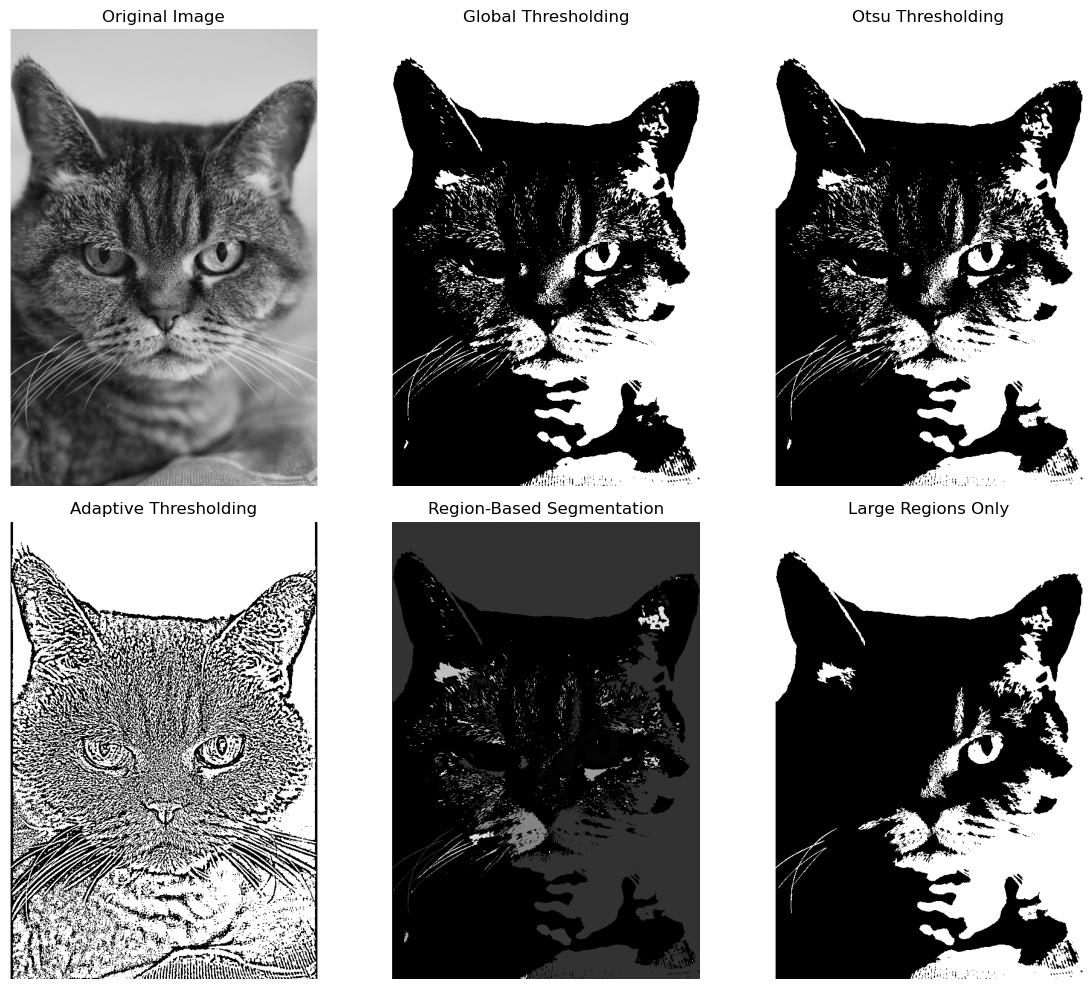

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Read Image
image = cv2.imread("cat.png", cv2.IMREAD_GRAYSCALE)

# 1. Global Thresholding
_, global_thresh = cv2.threshold(
    image,
    127,
    255,
    cv2.THRESH_BINARY
)


# 2. Otsu's Thresholding
otsu_thresh_value, otsu_thresh = cv2.threshold(
    image,
    0,
    255,
    cv2.THRESH_BINARY + cv2.THRESH_OTSU
)


# 3. Adaptive Thresholding
adaptive_thresh = cv2.adaptiveThreshold(
    image,
    255,
    cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
    cv2.THRESH_BINARY,
    11,
    2
)


# 4. Region-Based Segmentation
#    Using Connected Components
# Use binary image for segmentation
binary = otsu_thresh.copy()

num_labels, labels, stats, centroids = cv2.connectedComponentsWithStats(
    binary,
    connectivity=8
)

# Create output image
region_segmented = np.zeros_like(image)

# Assign different intensity values to different regions
for i in range(1, num_labels):
    region_segmented[labels == i] = (i * 50) % 256


# 5. Keep Only Large Regions
min_area = 500

large_regions = np.zeros_like(image)

for i in range(1, num_labels):

    area = stats[i, cv2.CC_STAT_AREA]

    if area >= min_area:
        large_regions[labels == i] = 255


# Display Results
plt.figure(figsize=(12, 10))

plt.subplot(2, 3, 1)
plt.imshow(image, cmap="gray")
plt.title("Original Image")
plt.axis("off")

plt.subplot(2, 3, 2)
plt.imshow(global_thresh, cmap="gray")
plt.title("Global Thresholding")
plt.axis("off")

plt.subplot(2, 3, 3)
plt.imshow(otsu_thresh, cmap="gray")
plt.title("Otsu Thresholding")
plt.axis("off")

plt.subplot(2, 3, 4)
plt.imshow(adaptive_thresh, cmap="gray")
plt.title("Adaptive Thresholding")
plt.axis("off")

plt.subplot(2, 3, 5)
plt.imshow(region_segmented, cmap="gray")
plt.title("Region-Based Segmentation")
plt.axis("off")

plt.subplot(2, 3, 6)
plt.imshow(large_regions, cmap="gray")
plt.title("Large Regions Only")
plt.axis("off")

plt.tight_layout()
plt.show()

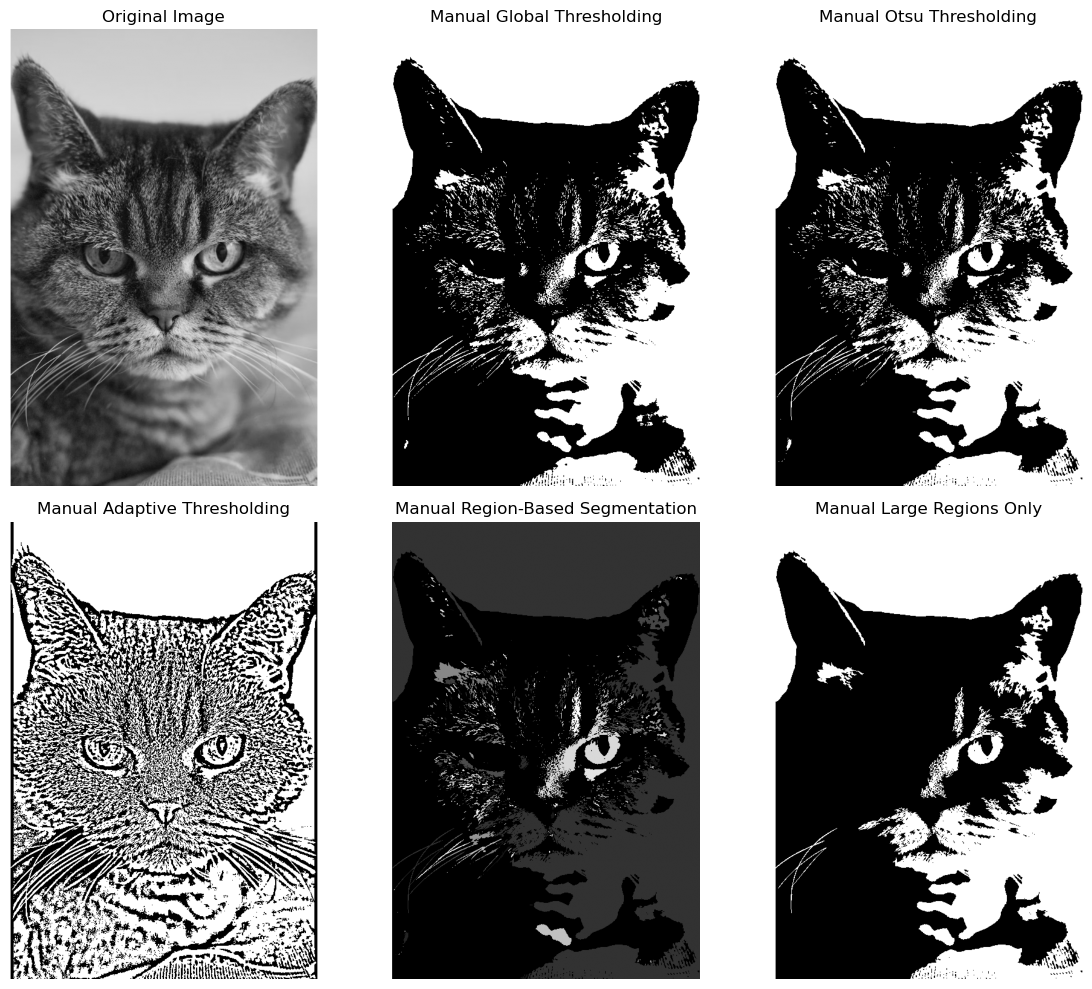

In [ ]:
# Manual implementation of the same problem using custom logic
# This solves the same task without using OpenCV thresholding/connectedComponents helpers

import cv2
import numpy as np
import matplotlib.pyplot as plt

# Read image
image = cv2.imread("cat.png", cv2.IMREAD_GRAYSCALE)

# 1. Manual Global Thresholding
def manual_global_threshold(img, T=127):
    out = np.zeros_like(img)
    out[img >= T] = 255
    return out

# 2. Manual Otsu Thresholding
def manual_otsu_threshold(img):
    hist, _ = np.histogram(img, bins=256, range=(0, 256))
    total = img.size
    sum_hist = np.arange(256) * hist
    total_sum = sum_hist.sum()
    sumB = 0.0
    wB = 0
    max_var = 0.0
    threshold = 0

    for t in range(256):
        wB += hist[t]
        if wB == 0:
            continue
        wF = total - wB
        if wF == 0:
            break
        sumB += t * hist[t]
        mB = sumB / wB
        mF = (total_sum - sumB) / wF
        var_between = wB * wF * (mB - mF) ** 2
        if var_between > max_var:
            max_var = var_between
            threshold = t

    out = np.zeros_like(img)
    out[img >= threshold] = 255
    return threshold, out

# 3. Manual Adaptive Thresholding
def manual_adaptive_threshold(img, block_size=11, C=2):
    pad = block_size // 2
    h, w = img.shape
    out = np.zeros_like(img)
    img_pad = np.pad(img, pad, mode='edge')

    for y in range(h):
        for x in range(w):
            patch = img_pad[y:y + block_size, x:x + block_size]
            local_mean = np.mean(patch)
            threshold = local_mean - C
            out[y, x] = 255 if img[y, x] >= threshold else 0
    return out

# 4. Manual Region-Based Segmentation
def manual_connected_components(binary_img):
    h, w = binary_img.shape
    visited = np.zeros_like(binary_img, dtype=bool)
    labels = np.zeros_like(binary_img, dtype=int)
    components = []
    label = 0

    for y in range(h):
        for x in range(w):
            if binary_img[y, x] == 0 or visited[y, x]:
                continue

            label += 1
            stack = [(y, x)]
            visited[y, x] = True
            pixels = []

            while stack:
                cy, cx = stack.pop()
                pixels.append((cy, cx))
                for ny in range(max(0, cy - 1), min(h, cy + 2)):
                    for nx in range(max(0, cx - 1), min(w, cx + 2)):
                        if binary_img[ny, nx] != 0 and not visited[ny, nx]:
                            visited[ny, nx] = True
                            stack.append((ny, nx))

            components.append(pixels)
            for py, px in pixels:
                labels[py, px] = label

    return labels, components

# 5. Keep Only Large Regions
def keep_large_regions(labels, min_area=500):
    h, w = labels.shape
    out = np.zeros((h, w), dtype=np.uint8)
    region_areas = {}

    for y in range(h):
        for x in range(w):
            label = labels[y, x]
            if label != 0:
                region_areas[label] = region_areas.get(label, 0) + 1

    for y in range(h):
        for x in range(w):
            label = labels[y, x]
            if label != 0 and region_areas.get(label, 0) >= min_area:
                out[y, x] = 255
    return out

# ----- Apply manual methods -----
global_thresh = manual_global_threshold(image, 127)
otsu_value, otsu_thresh = manual_otsu_threshold(image)
adaptive_thresh = manual_adaptive_threshold(image, 11, 2)

# Use Otsu binary image for region-based segmentation
binary = otsu_thresh.copy()
labels, components = manual_connected_components(binary)
region_segmented = np.zeros_like(image)
for i in range(1, len(components) + 1):
    region_segmented[labels == i] = (i * 50) % 256

large_regions = keep_large_regions(labels, min_area=500)

# Display results
plt.figure(figsize=(12, 10))

plt.subplot(2, 3, 1)
plt.imshow(image, cmap="gray")
plt.title("Original Image")
plt.axis("off")

plt.subplot(2, 3, 2)
plt.imshow(global_thresh, cmap="gray")
plt.title("Manual Global Thresholding")
plt.axis("off")

plt.subplot(2, 3, 3)
plt.imshow(otsu_thresh, cmap="gray")
plt.title("Manual Otsu Thresholding")
plt.axis("off")

plt.subplot(2, 3, 4)
plt.imshow(adaptive_thresh, cmap="gray")
plt.title("Manual Adaptive Thresholding")
plt.axis("off")

plt.subplot(2, 3, 5)
plt.imshow(region_segmented, cmap="gray")
plt.title("Manual Region-Based Segmentation")
plt.axis("off")

plt.subplot(2, 3, 6)
plt.imshow(large_regions, cmap="gray")
plt.title("Manual Large Regions Only")
plt.axis("off")

plt.tight_layout()
plt.show()
